This notebook contains early work confirming that hydro coefficients from pseudo-slant (staircase approximation), computed using both MEEM and Capytaine, is the same as the true slant values (with Capytaine). There is also a solve time comparison, but not very useful because we havn't minimized MEEM regions/NMK or Capytaine panel count.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

import capytaine as cpt

import sys
from pathlib import Path

HERE = Path.cwd().resolve()
dir_path_str = str((HERE / "..").resolve())
if dir_path_str not in sys.path:
  sys.path.insert(0, dir_path_str)
from multi_condensed import Problem
from capytaine_generator import CapytaineSlantSolver

# removes capytaine warnings from clogging outputs
import logging
logging.getLogger("capytaine").setLevel(logging.ERROR)

In [5]:
# Variable definitions
def makeSlant(d1, d2, a1, a2, resolu, terms): # get staircase geometry dimensions to approximate frustrum
    d = np.linspace(d1, d2, resolu)
    a = a1 + (d1-d) * (a2-a1) / (d1-d2)
    heaving = np.ones(resolu, dtype=int)
    NMK = np.full(resolu+1, terms) 
    return d.tolist(), a.tolist(), heaving.tolist(), NMK.tolist()

d1, d2, a1, a2 = 0.5, 0.25, 0.25, 0.5
resolu = 25 #number of mini cylinders (subdivisions) the slant object has
terms = 50 #number of terms in each region
d, a, heaving, NMK = makeSlant(d1, d2, a1, a2, resolu, terms)

m0_nums_MEEM = np.concatenate((np.linspace(0.1, 1, 20), np.linspace(1.25, 6, 20)))
m0_nums_CPT = np.concatenate((np.linspace(0.1, 1, 5), np.linspace(1.5, 6, 10)))
h = 1.001
g = 9.81
rho = 1023
####################################################

In [6]:
# Calculate pseudo-slant with MEEM
hydro_collector_real_MEEM = []
hydro_collector_imag_MEEM = []
times_MEEM = []

for m0 in m0_nums_MEEM:
    start = time.perf_counter()
    prob = Problem(h, d, a, heaving, NMK, m0, rho)
    a0 = prob.a_matrix()
    b0 = prob.b_vector()
    x = prob.get_unknown_coeffs(a0, b0)
    am, dp = prob.hydro_coeffs(x, "nondimensional")
    hydro_collector_real_MEEM.append(am)
    hydro_collector_imag_MEEM.append(dp)
    end = time.perf_counter()
    times_MEEM.append(end - start)

In [7]:
# Calculate pseudo-slant with Capytaine

css = CapytaineSlantSolver(False, False, False, False, False)
def compute_cpt_pseudo(a, d, heaving, t_densities, face_units, m0, h, rho):
    results = css.construct_and_solve(a, d, d, heaving, t_densities, face_units, h, None, rho, m0 = m0)
    am = np.array(list(results[0].added_mass.values()))
    dp = np.array(list(results[0].radiation_damping.values()))
    am_nondim = h**3 / (rho * np.pi * max(a)**3) * am
    dp_nondim = h**3 / (css.omega_from_wavenumber(m0, h) * rho * np.pi * max(a)**3) * dp
    print("Panel Count: ", results[-1])
    return am, dp, am_nondim, dp_nondim

t_densities = np.full(resolu, 50).tolist() # number of panels around each cylinder
face_units = 50 # number of panels along the outline of the configuration
results = [compute_cpt_pseudo(a, d, heaving, t_densities, face_units, m0, h, rho) for m0 in m0_nums_CPT]

hydro_collector_real_CPT = [res[2].flatten() for res in results]
hydro_collector_imag_CPT = [res[3].flatten() for res in results]


Panel Count:  2500
Panel Count:  2500
Panel Count:  2500
Panel Count:  2500
Panel Count:  2500
Panel Count:  2500
Panel Count:  2500
Panel Count:  2500
Panel Count:  2500
Panel Count:  2500
Panel Count:  2500
Panel Count:  2500
Panel Count:  2500
Panel Count:  2500
Panel Count:  2500


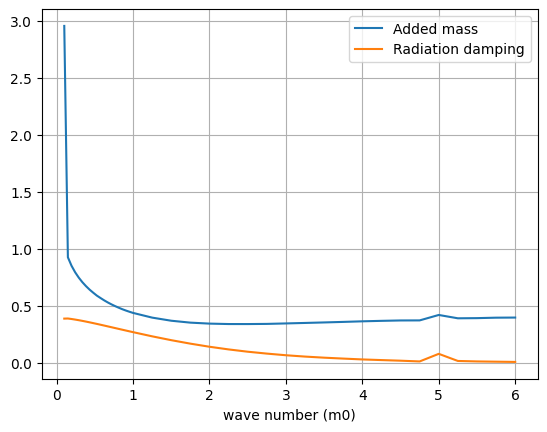

In [ ]:
############################################## CAPYTAINE Real Slant ############################################################

# Profile of the axisymmetric body
def shape(z):
    if z >= -0.25:
        return 0.5
    elif z < -0.25 and z >= -0.49999:
        return z + 0.75
    elif z < -0.49999 and z <= -0.5:
        return 25000*z+12500 #approximating a the bottom surface

# Generate the mesh and display it with VTK.
buoy = cpt.FloatingBody(
    mesh=cpt.AxialSymmetricMesh.from_profile(shape, z_range=np.linspace(-0.5, 0, 100), nphi=100)
)
buoy.add_translation_dof(name="Heave")
buoy.show_matplotlib()

# Set up problems
problems = [cpt.RadiationProblem(body=buoy, radiating_dof='Heave', wavenumber = m0, water_depth = h, rho = rho)
            for m0 in m0_nums_MEEM]

# Solve the problems using the axial symmetry
solver = cpt.BEMSolver(engine=cpt.HierarchicalToeplitzMatrixEngine())

results = []
times_CPT = []
for pb in problems:
    t0 = time.perf_counter()
    res = solver.solve(pb)
    t1 = time.perf_counter()

    results.append(res)
    times_CPT.append(t1 - t0)
    
dataset = cpt.io.xarray.assemble_dataset(results)

h = 1.001
rho = 1023  # density of our special material
g = 9.81
omega = dataset['omega']
# omega = sqrt(m0 * np.tanh(m0 * h) * g)
A = dataset['added_mass'].sel(radiating_dof='Heave',influenced_dof='Heave')
B = dataset['radiation_damping'].sel(radiating_dof='Heave', influenced_dof='Heave')
A_nondim = h**3 / (rho * np.pi * 0.5**3) * A                # 0.5 is the radius of the slant object
B_nondim = h**3 / (omega * rho * np.pi * 0.5**3) * B        # 0.5 is the radius of the slant object
# Plot results
plt.figure()
plt.plot(m0_nums_MEEM, A_nondim, label="Added mass")
plt.plot( m0_nums_MEEM, B_nondim, label="Radiation damping")
plt.xlabel('wave number (m0)')
plt.grid()
plt.legend()
plt.show()

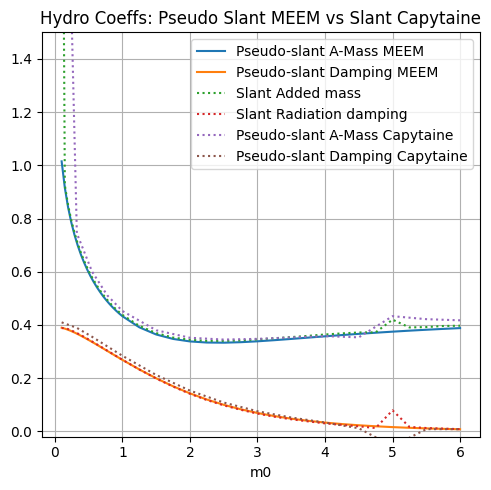

In [11]:
# Create the hydro comparison plots
plt.figure(figsize=(5,5))
plt.plot(m0_nums_MEEM, hydro_collector_real_MEEM, label='Pseudo-slant A-Mass MEEM', linestyle='-')
plt.plot(m0_nums_MEEM, hydro_collector_imag_MEEM, label='Pseudo-slant Damping MEEM', linestyle='-')
plt.plot(m0_nums_MEEM, A_nondim, label="Slant Added mass", linestyle=':')
plt.plot(m0_nums_MEEM, B_nondim, label="Slant Radiation damping",linestyle=':')
plt.plot(m0_nums_CPT, hydro_collector_real_CPT, label='Pseudo-slant A-Mass Capytaine',  linestyle=':')
plt.plot(m0_nums_CPT, hydro_collector_imag_CPT, label='Pseudo-slant Damping Capytaine',  linestyle=':') 

plt.xlabel('m0')
plt.ylabel('')
plt.title('Hydro Coeffs: Pseudo Slant MEEM vs Slant Capytaine')
plt.legend(loc='best')
plt.grid(True)
plt.ylim(-0.02, 1.5)

plt.tight_layout()
plt.show()

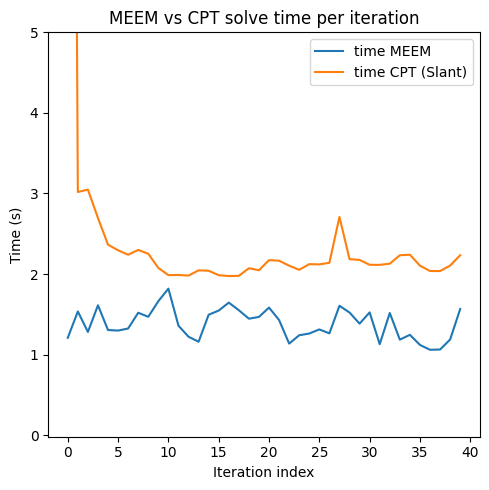

In [12]:
###graphing time difference###
plt.figure(figsize=(5, 5))
plt.plot(times_MEEM, label='time MEEM')
plt.plot(times_CPT, label='time CPT (Slant)')
plt.xlabel('Iteration index')
plt.ylabel('Time (s)')
plt.title('MEEM vs CPT solve time per iteration')
plt.ylim(-0.02, 5)
plt.legend()
plt.tight_layout()
plt.show()

# Not pictured: despite having less panels, the cpt pseudo slant takes much longer to run than cpt slant
# This is likely an inefficiency in our code.